# Multiplanet Distribution Validation

Validate the output of `multiplanet_draw_planet_arrays.py` against expected distributions:
- **Planet counts**: Poisson(λ≈3.0) from integrated Suzuki, capped at 2
- **Mass/Semi-major axis**: Suzuki broken power-law distribution
- **Period ratio**: Must be > 1.3 for 2-planet systems
- **Eccentricity**: Half-Gaussian (σ=0.3)
- **Inclination**: Gaussian scatter around 1000° (GULLS binary convention)
- **Longitudes**: Uniform in [0, 360)

In [104]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load all planet files
data_dir = "planets/test_multiplanet"
files = sorted(glob.glob(f"{data_dir}/*.planets.*.*"))
print(f"Found {len(files)} planet files")

# Combine all data
all_data = []
for f in files[:]:  # Limit for quick testing
    d = np.loadtxt(f, skiprows=1)
    all_data.append(d)
    
data = np.vstack(all_data)
n_rows = len(data)
n_systems = n_rows
ncolumns = len(data[0])
n_slots = ncolumns // 7
print(f"Loaded {n_rows} rows ({n_systems} systems)")

# Current format: (n_systems, 14) - [system, (object 1 parameters*, object 2 parameters*)]
# Reshape to (n_systems, 3, 7) - [system, object_type, parameter]
data_3d = np.zeros((n_systems, 3, 7))
for i in range(n_systems):
    data_3d[i, 0, :] = data[i, :7]
    companion = data[i, 7:]
    if companion[0] == 0:  # no companion
        data_3d[i, 1, :] = companion  # planet
        data_3d[i, 2, :-1] = np.zeros(6)  # moon
        data_3d[i, 2, -1] = 3  # moon orbit type
    elif companion[-1] == 3:  # satelite companiom (moon)
        data_3d[i, 1, :-1] = np.zeros(6)  # planet
        data_3d[i, 1, -1] = 2  # planet orbit type
        data_3d[i, 2, :] = companion  # moon
    else:
        data_3d[i, 1, :-1] = companion[:-1]  # planet
        data_3d[i, 2, :-1] = np.zeros(6)  # moon
        data_3d[i, 1, -1] = 2  # planet orbit type
        data_3d[i, 2, -1] = 3  # moon orbit type

#data_3d = data.reshape(n_systems, 1, 14)
print(f"Shape: {data_3d.shape}")

# Column indices
MASS, SEMI_A, ECC, INC, OMEGA, LONG_NODE, ORBIT_TYPE = range(7)

Found 1231 planet files
Loaded 1231000 rows (1231000 systems)
Shape: (1231000, 3, 7)


## Planet Count Distribution

Count how many planets (OrbitType 1 or 2 with mass > 0) each system has.

planets_only shape: (2379614, 7)
Systems with 0 planets: 0 (0.0%)
Systems with 1 planet:  82386 (6.7%)
Systems with 2 planets: 1148614 (93.3%)
Mean planets/system: 1.933


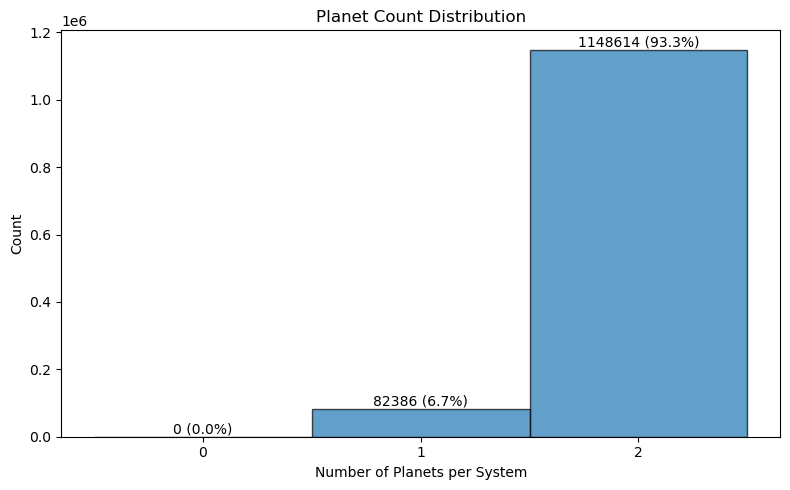

In [105]:
# Count planets per system (OrbitType 1 or 2 with mass > 0)
planets_mask = (data_3d[:, :2, MASS] > 0)  # Only first two slots (planets, not moon)
n_planets_per_system = planets_mask.sum(axis=1)

# stack of only planetary objects
planets_only = data_3d[:, :2, :][planets_mask]
print(f"planets_only shape: {planets_only.shape}")

fig, ax = plt.subplots(figsize=(8, 5))
counts, bins, _ = ax.hist(n_planets_per_system, bins=[-0.5, 0.5, 1.5, 2.5], 
                          edgecolor='black', alpha=0.7)
ax.set_xlabel("Number of Planets per System")
ax.set_ylabel("Count")
ax.set_title("Planet Count Distribution")
ax.set_xticks([0, 1, 2])

# Annotate with percentages
for i, c in enumerate(counts):
    pct = 100 * c / n_systems
    ax.annotate(f'{int(c)} ({pct:.1f}%)', xy=(i, c), ha='center', va='bottom', fontsize=10)

# Summary stats
print(f"Systems with 0 planets: {(n_planets_per_system == 0).sum()} ({100*(n_planets_per_system == 0).mean():.1f}%)")
print(f"Systems with 1 planet:  {(n_planets_per_system == 1).sum()} ({100*(n_planets_per_system == 1).mean():.1f}%)")
print(f"Systems with 2 planets: {(n_planets_per_system == 2).sum()} ({100*(n_planets_per_system == 2).mean():.1f}%)")
print(f"Mean planets/system: {n_planets_per_system.mean():.3f}")
plt.tight_layout()
plt.show()

## Mass and Semi-Major Axis Distributions

Drawn from Suzuki broken power-law (favors lower masses below q_br ≈ 1.7×10⁻⁴).

Total objects: 2407412, Mean per system: 1.956
Total moons: 27798, Mean moons/system: 0.023
Total planets: 2379614, Mean planets/system: 1.933


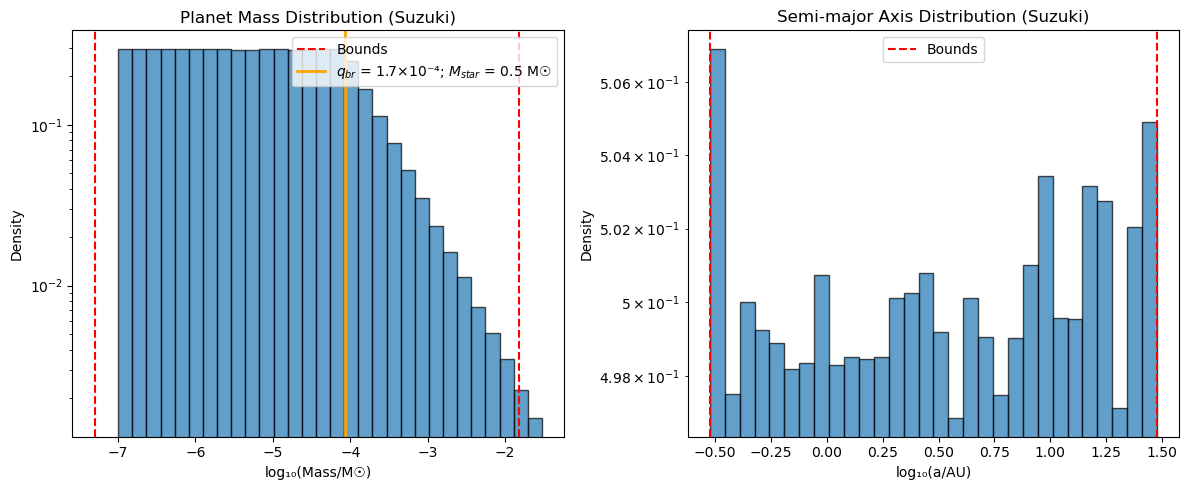

In [106]:
# Remove systems with no planets
all_planets = data_3d[data_3d[:, 0,  MASS] > 0]
object_counts = (all_planets[:, :, MASS] > 0).sum(axis=1)
print(f"Total objects: {object_counts.sum()}, Mean per system: {object_counts.mean():.3f}")

# Separate planets from moons
moons_only = data_3d[all_planets[:, 2, MASS] > 0]
n_moons = len(moons_only)
print(f"Total moons: {n_moons}, Mean moons/system: {n_moons/n_systems:.3f}")
print(f"Total planets: {object_counts.sum()-n_moons}, Mean planets/system: {(object_counts.sum()-n_moons)/n_systems:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Mass distribution (log scale)
ax = axes[0]
log_mass = np.log10(planets_only[:, MASS])
ax.hist(log_mass, bins=30, edgecolor='black', alpha=0.7, density=True)
ax.axvline(np.log10(1e-7*0.5), color='r', ls='--', label='Bounds')
ax.axvline(np.log10(3e-2*0.5), color='r', ls='--')
ax.axvline(np.log10(1.7e-4*0.5), color='orange', ls='-', lw=2, label=r'$q_{br}$ = 1.7×10⁻⁴; $M_{star}$ = 0.5 M☉')
ax.set_xlabel("log₁₀(Mass/M☉)")
ax.set_ylabel("Density")
ax.set_title("Planet Mass Distribution (Suzuki)")
ax.set_yscale('log')
ax.legend()

# Semi-major axis distribution (log scale)
ax = axes[1]
log_a = np.log10(planets_only[:, SEMI_A])
ax.hist(log_a, bins=30, edgecolor='black', alpha=0.7, density=True)
ax.axvline(np.log10(0.3), color='r', ls='--', label='Bounds')
ax.axvline(np.log10(30), color='r', ls='--')
ax.set_xlabel("log₁₀(a/AU)")
ax.set_ylabel("Density")
ax.set_title("Semi-major Axis Distribution (Suzuki)")
ax.legend()
ax.set_yscale('log')

plt.tight_layout()
plt.show()

## Period Ratio Check

For 2-planet systems, the period ratio must be > 1.3 for stability.

Period ratio violations (< 1.3): 0 (0.0%)
Min period ratio: 1.300
Mean period ratio: 44.64


/var/folders/yk/2lp5vmnd6s778_4bh__0mvyc0000gp/T/ipykernel_85172/3077122220.py:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


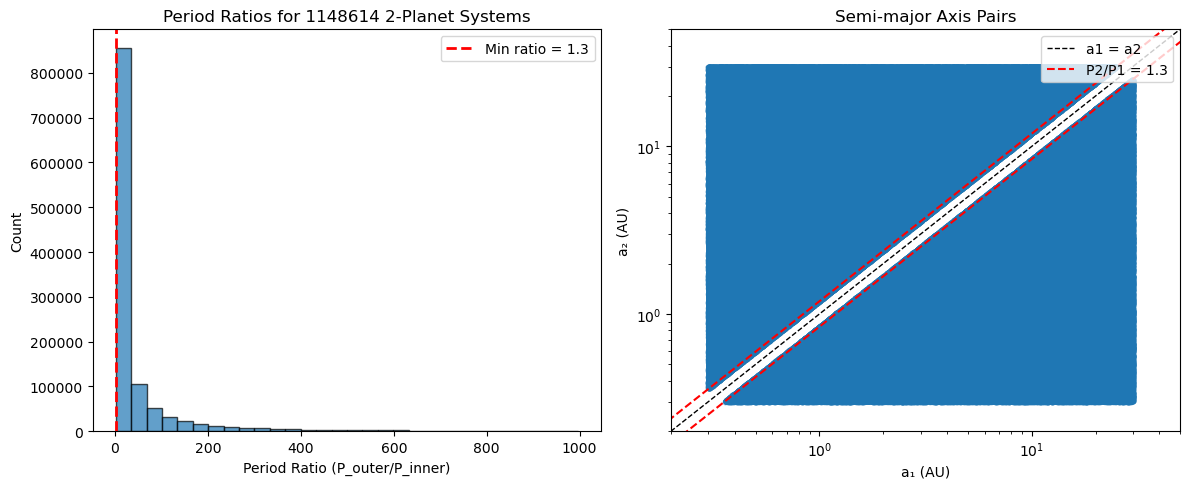

In [107]:
# Find 2-planet systems
two_planet_mask = (n_planets_per_system == 2)
two_planet_systems = data_3d[two_planet_mask]

a1 = two_planet_systems[:, 0, SEMI_A]
a2 = two_planet_systems[:, 1, SEMI_A]

# Period ratio: P2/P1 = (a2/a1)^1.5, always take the larger ratio
period_ratio = np.maximum(a2/a1, a1/a2) ** 1.5

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
ax = axes[0]
ax.hist(period_ratio, bins=30, edgecolor='black', alpha=0.7)
ax.axvline(1.3, color='r', ls='--', lw=2, label='Min ratio = 1.3')
ax.set_xlabel("Period Ratio (P_outer/P_inner)")
ax.set_ylabel("Count")
ax.set_title(f"Period Ratios for {len(two_planet_systems)} 2-Planet Systems")
ax.legend()

# Check violations
violations = period_ratio < 1.3
print(f"Period ratio violations (< 1.3): {violations.sum()} ({100*violations.mean():.1f}%)")
print(f"Min period ratio: {period_ratio.min():.3f}")
print(f"Mean period ratio: {period_ratio.mean():.2f}")

# Scatter plot
ax = axes[1]
ax.scatter(a1, a2, alpha=0.5, s=10)
ax.plot([0.1, 100], [0.1, 100], 'k--', lw=1, label='a1 = a2')
# Plot 1.3 ratio boundaries
a_vals = np.logspace(-1, 2, 100)
ax.plot(a_vals, a_vals * 1.3**(2/3), 'r--', label='P2/P1 = 1.3')
ax.plot(a_vals, a_vals / 1.3**(2/3), 'r--')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("a₁ (AU)")
ax.set_ylabel("a₂ (AU)")
ax.set_title("Semi-major Axis Pairs")
ax.legend()
ax.set_xlim(0.2, 50)
ax.set_ylim(0.2, 50)

plt.tight_layout()
plt.show()

## Eccentricity Distribution

Should be half-Gaussian with σ=0.3, truncated at 0.95.

Mean eccentricity: 0.421
Max eccentricity: 0.900


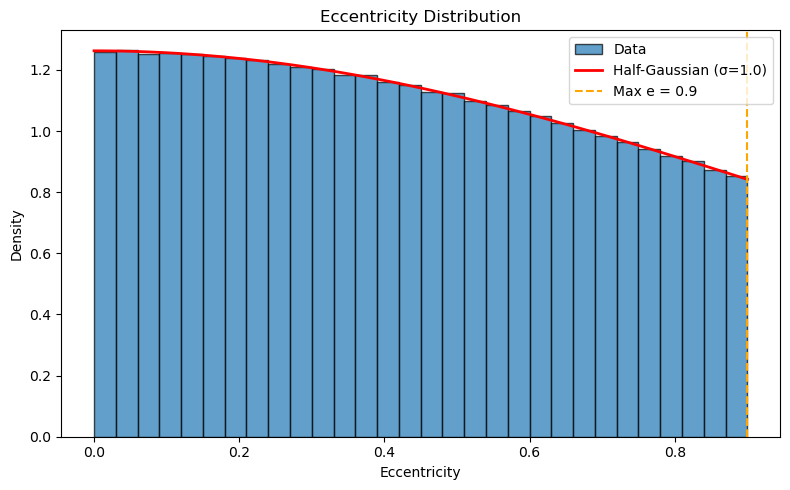

In [108]:
from scipy import special

fig, ax = plt.subplots(figsize=(8, 5))

ecc = planets_only[:, ECC]
ax.hist(ecc, bins=30, edgecolor='black', alpha=0.7, density=True, label='Data')

# Expected half-Gaussian
max_e = 0.9
sigma = 1.0
mean_e = 0.0
e_vals = np.linspace(0, max_e, 100)
A = 2.0 / special.erf(max_e / (np.sqrt(2) * sigma)) 
half_gauss = A * stats.norm.pdf(e_vals, mean_e, sigma)  # Truncated
ax.plot(e_vals, half_gauss, 'r-', lw=2, label=f'Half-Gaussian (σ={sigma})')

ax.axvline(max_e, color='orange', ls='--', label=f'Max e = {max_e}')
ax.set_xlabel("Eccentricity")
ax.set_ylabel("Density")
ax.set_title("Eccentricity Distribution")
ax.legend()

print(f"Mean eccentricity: {ecc.mean():.3f}")
print(f"Max eccentricity: {ecc.max():.3f}")
plt.tight_layout()
plt.show()

## Inclination Distribution

GULLS convention: I > 900 means relative to binary orbit.
- I = 1000 means coplanar with binary
- Actual inclination = I_binary + (I - 1000)

Our draw: Gaussian centered on 1000 with σ=5°.

Mean inclination: 1000.0°
Std of (I - 1000): 0.00°


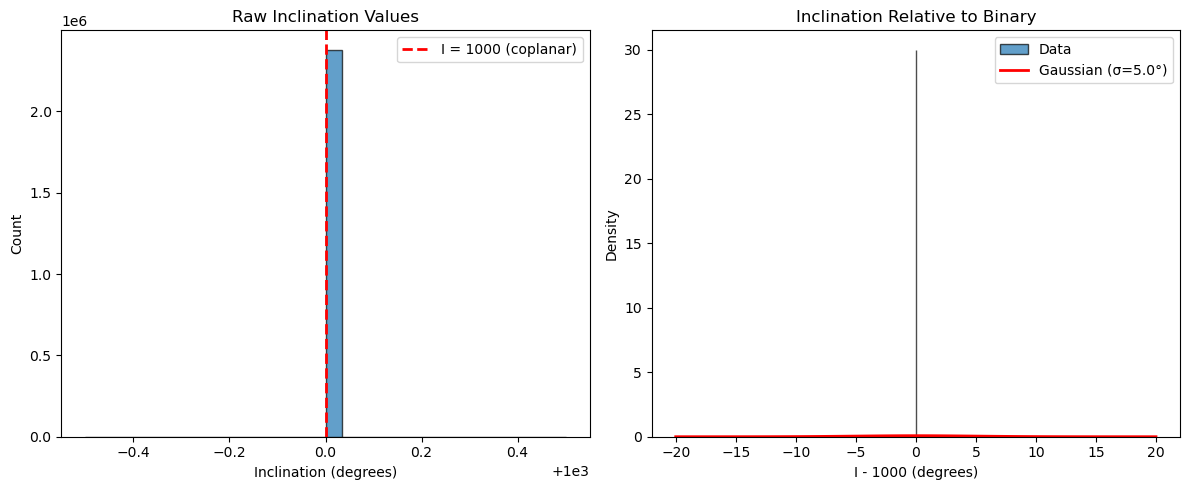

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

inc = planets_only[:, INC]

# Raw inclination values
ax = axes[0]
ax.hist(inc, bins=30, edgecolor='black', alpha=0.7)
ax.axvline(1000, color='r', ls='--', lw=2, label='I = 1000 (coplanar)')
ax.set_xlabel("Inclination (degrees)")
ax.set_ylabel("Count")
ax.set_title("Raw Inclination Values")
ax.legend()

# Relative to 1000 (GULLS convention)
ax = axes[1]
relative_inc = inc - 1000
ax.hist(relative_inc, bins=30, edgecolor='black', alpha=0.7, density=True, label='Data')

# Expected Gaussian
x = np.linspace(-20, 20, 100)
sigma = 5.0
ax.plot(x, stats.norm.pdf(x, 0, sigma), 'r-', lw=2, label=f'Gaussian (σ={sigma}°)')
ax.set_xlabel("I - 1000 (degrees)")
ax.set_ylabel("Density")
ax.set_title("Inclination Relative to Binary")
ax.legend()

print(f"Mean inclination: {inc.mean():.1f}°")
print(f"Std of (I - 1000): {relative_inc.std():.2f}°")
plt.tight_layout()
plt.show()

## Longitude Distributions

Both should be uniform in [0, 360).

KS test for ω uniformity: statistic=0.0004, p=0.8792
KS test for Ω uniformity: statistic=0.0009, p=0.0278


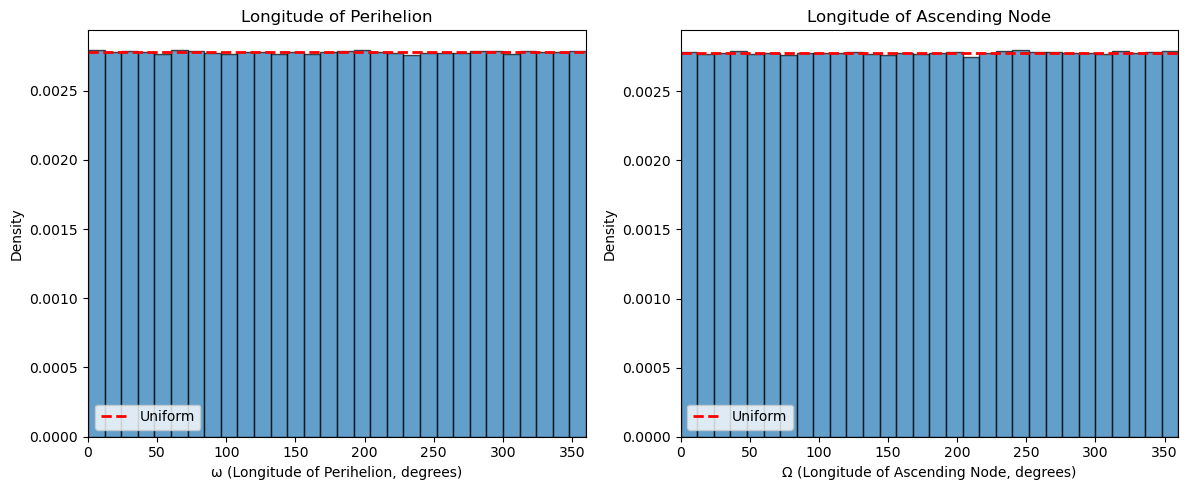

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Longitude of perihelion
ax = axes[0]
omega = planets_only[:, OMEGA]
ax.hist(omega, bins=30, edgecolor='black', alpha=0.7, density=True)
ax.axhline(1/360, color='r', ls='--', lw=2, label='Uniform')
ax.set_xlabel("ω (Longitude of Perihelion, degrees)")
ax.set_ylabel("Density")
ax.set_title("Longitude of Perihelion")
ax.set_xlim(0, 360)
ax.legend()

# Longitude of ascending node
ax = axes[1]
Omega = planets_only[:, LONG_NODE]
ax.hist(Omega, bins=30, edgecolor='black', alpha=0.7, density=True)
ax.axhline(1/360, color='r', ls='--', lw=2, label='Uniform')
ax.set_xlabel("Ω (Longitude of Ascending Node, degrees)")
ax.set_ylabel("Density")
ax.set_title("Longitude of Ascending Node")
ax.set_xlim(0, 360)
ax.legend()

# KS test for uniformity
ks_omega = stats.kstest(omega, 'uniform', args=(0, 360))
ks_Omega = stats.kstest(Omega, 'uniform', args=(0, 360))
print(f"KS test for ω uniformity: statistic={ks_omega.statistic:.4f}, p={ks_omega.pvalue:.4f}")
print(f"KS test for Ω uniformity: statistic={ks_Omega.statistic:.4f}, p={ks_Omega.pvalue:.4f}")

plt.tight_layout()
plt.show()

## Moon Semi-Major Axis and Hill Radii

The moon semi-major axis has a fix lower limit in au and an upper limit dependent on the host planets Hill radii:

$$ R_{\mathrm{H}} \approx a \sqrt[3]{\frac{m_2}{3(m_1+m_2)}} \approx a \sqrt[3]{\frac{1}{3(\frac{m_1}{m_2}+1)}} $$

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


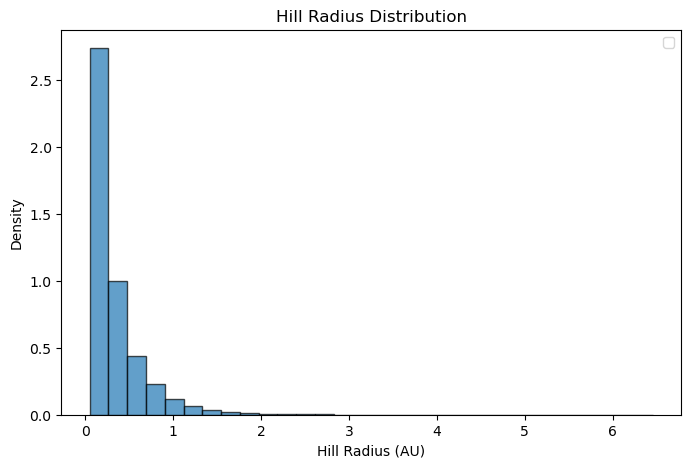

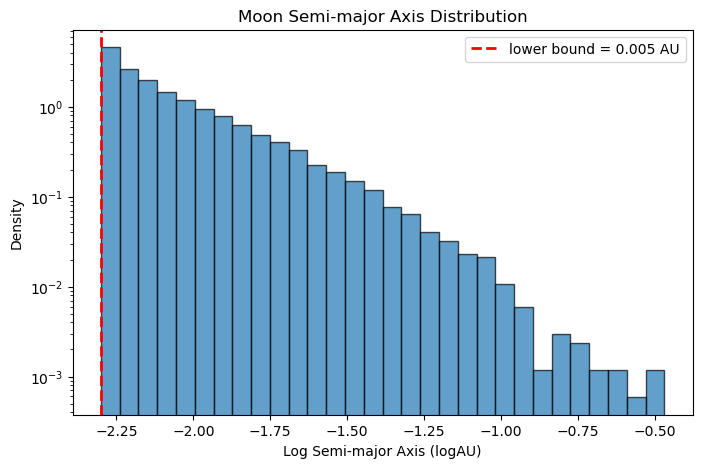

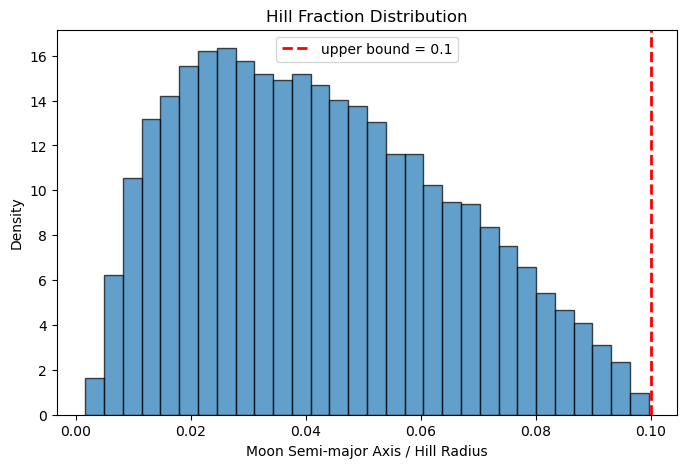

In [111]:
HOST_STAR_MASS = 0.5
min_moon_semi_major_axis = 0.005
MOON_HILL_FRACTION = 0.1

def hill_radius(a, m1, m2):
    return a * (m2 / (3 * (m1 + m2)))**(1/3)

planets_with_moons = data_3d[data_3d[:, 2, MASS] > 0]

hill_radii = hill_radius(planets_with_moons[:, 0, SEMI_A], HOST_STAR_MASS, planets_with_moons[:, 0, MASS])

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(hill_radii, bins=30, edgecolor='black', alpha=0.7, density=True)
ax.set_xlabel("Hill Radius (AU)")
ax.set_ylabel("Density")
ax.set_title("Hill Radius Distribution")
ax.legend()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(np.log10(planets_with_moons[:, 2, SEMI_A]), bins=30, edgecolor='black', alpha=0.7, density=True)
ax.axvline(np.log10(min_moon_semi_major_axis), color='r', ls='--', lw=2, label=f'lower bound = {min_moon_semi_major_axis} AU')
ax.set_xlabel("Log Semi-major Axis (logAU)")
ax.set_ylabel("Density")
ax.set_title("Moon Semi-major Axis Distribution")
ax.set_yscale('log')
ax.legend()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(planets_with_moons[:, 2, SEMI_A]/hill_radii, bins=30, edgecolor='black', alpha=0.7, density=True)
ax.axvline(MOON_HILL_FRACTION, color='r', ls='--', lw=2, label=f'upper bound = {MOON_HILL_FRACTION}')
ax.set_xlabel("Moon Semi-major Axis / Hill Radius")
ax.set_ylabel("Density")
ax.set_title("Hill Fraction Distribution")
ax.legend()

moons_only = planets_with_moons[:, 2, :]

## Summary Statistics

In [112]:
print("=" * 50)
print("MULTIPLANET GENERATOR VALIDATION SUMMARY")
print("=" * 50)
print(f"\nSystems analyzed: {n_systems}")
print(f"Total planets: {len(planets_only)}")
print(f"Total moons: {len(moons_only)}")
print(f"\nPlanet counts:")
print(f"  0 planets: {(n_planets_per_system == 0).sum()} ({100*(n_planets_per_system == 0).mean():.1f}%)")
print(f"  1 planet:  {(n_planets_per_system == 1).sum()} ({100*(n_planets_per_system == 1).mean():.1f}%)")
print(f"  2 planets: {(n_planets_per_system == 2).sum()} ({100*(n_planets_per_system == 2).mean():.1f}%)")
print(f"  Mean planets/star: {n_planets_per_system.mean():.3f}")
print(f"\nOrbital elements:")
print(f"  Mass range: {planets_only[:, MASS].min():.2e} - {planets_only[:, MASS].max():.2e} M☉")
print(f"  Semi-major axis: {planets_only[:, SEMI_A].min():.2f} - {planets_only[:, SEMI_A].max():.2f} AU")
print(f"  Eccentricity: {ecc.mean():.3f} ± {ecc.std():.3f}")
print(f"  Inclination - 1000: {relative_inc.mean():.2f}° ± {relative_inc.std():.2f}°")
print(f"\nPeriod ratio (2-planet systems):")
print(f"  Min: {period_ratio.min():.2f}")
print(f"  Mean: {period_ratio.mean():.2f}")
print(f"  Violations (< 1.3): {violations.sum()}")

MULTIPLANET GENERATOR VALIDATION SUMMARY

Systems analyzed: 1231000
Total planets: 2379614
Total moons: 27798

Planet counts:
  0 planets: 0 (0.0%)
  1 planet:  82386 (6.7%)
  2 planets: 1148614 (93.3%)
  Mean planets/star: 1.933

Orbital elements:
  Mass range: 1.00e-07 - 3.00e-02 M☉
  Semi-major axis: 0.30 - 30.00 AU
  Eccentricity: 0.421 ± 0.255
  Inclination - 1000: 0.00° ± 0.00°

Period ratio (2-planet systems):
  Min: 1.30
  Mean: 44.64
  Violations (< 1.3): 0
